In [4]:
import os
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

DATA_ROOT = "../data/CUB_200_2011"

# Load metadata
images = pd.read_csv(
    os.path.join(DATA_ROOT, "images.txt"),
    sep=" ",
    names=["image_id", "file_path"]
)

labels = pd.read_csv(
    os.path.join(DATA_ROOT, "image_class_labels.txt"),
    sep=" ",
    names=["image_id", "class_id"]
)

split = pd.read_csv(
    os.path.join(DATA_ROOT, "train_test_split.txt"),
    sep=" ",
    names=["image_id", "is_train"]
)

classes = pd.read_csv(
    os.path.join(DATA_ROOT, "classes.txt"),
    sep=" ",
    names=["class_id", "class_name"]
)

# Merge
df = images.merge(labels, on="image_id")
df = df.merge(split, on="image_id")
df = df.merge(classes, on="class_id")

df.head()


,image_id,file_path,class_id,is_train,class_name
0,1,001.Black_footed_Albatross/Black_Footed_Albatr...,1,0,001.Black_footed_Albatross
1,2,001.Black_footed_Albatross/Black_Footed_Albatr...,1,1,001.Black_footed_Albatross
2,3,001.Black_footed_Albatross/Black_Footed_Albatr...,1,0,001.Black_footed_Albatross
3,4,001.Black_footed_Albatross/Black_Footed_Albatr...,1,1,001.Black_footed_Albatross
4,5,001.Black_footed_Albatross/Black_Footed_Albatr...,1,1,001.Black_footed_Albatross


In [5]:
print("Total images:", len(df))
print("Number of classes:", df["class_id"].nunique())

print("Train images:", len(df[df.is_train == 1]))
print("Test images:", len(df[df.is_train == 0]))


Total images: 11788
Number of classes: 200
Train images: 5994
Test images: 5794


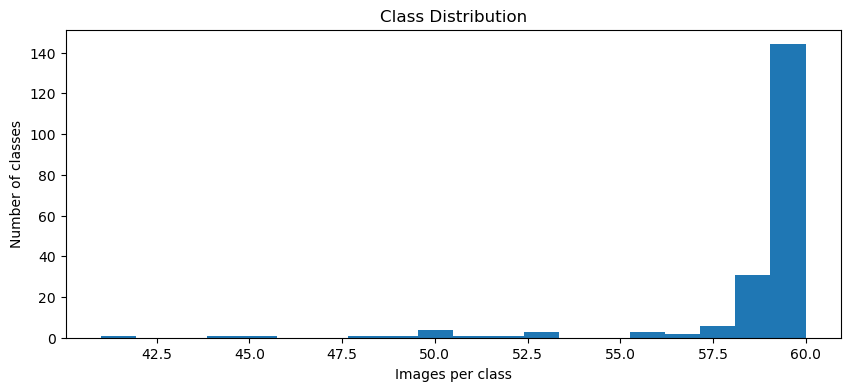

Min per class: 41
Max per class: 60


In [6]:
class_counts = df.groupby("class_name").size()

plt.figure(figsize=(10,4))
plt.hist(class_counts, bins=20)
plt.title("Class Distribution")
plt.xlabel("Images per class")
plt.ylabel("Number of classes")
plt.show()

print("Min per class:", class_counts.min())
print("Max per class:", class_counts.max())


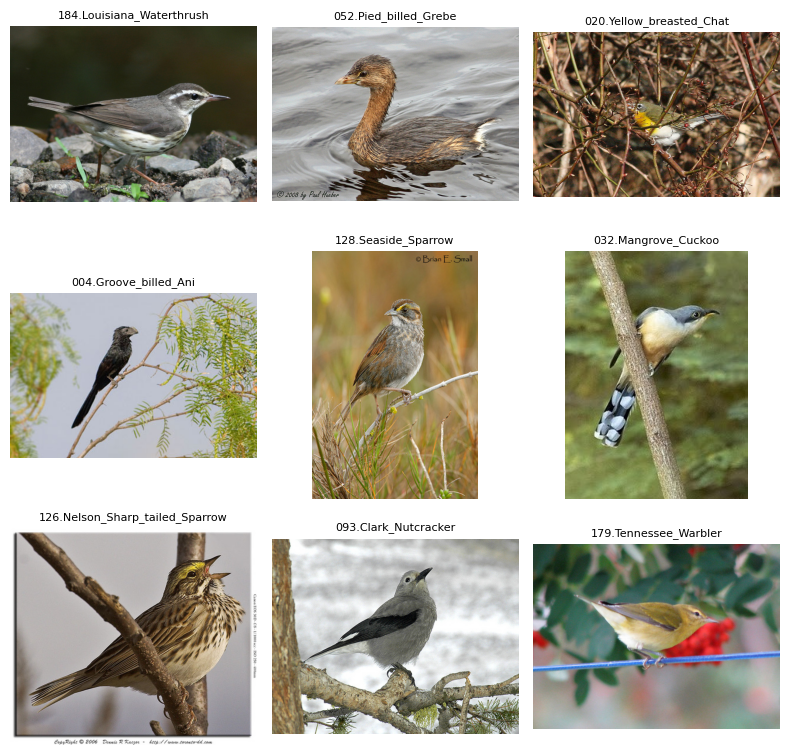

In [7]:
import random

sample_df = df.sample(9)

plt.figure(figsize=(8,8))

for i, (_, row) in enumerate(sample_df.iterrows()):
    img_path = os.path.join(DATA_ROOT, "images", row["file_path"])
    img = Image.open(img_path).convert("RGB")
    
    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(row["class_name"], fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()


Width mean: 467.392
Height mean: 392.32


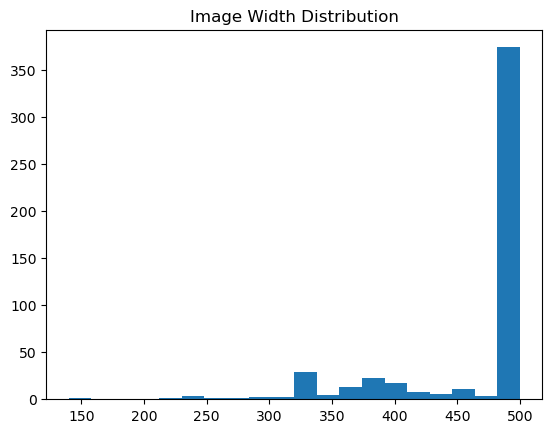

In [ ]:
sizes = []

for _, row in df.sample(500).iterrows():
    img_path = os.path.join(DATA_ROOT, "images", row["file_path"])
    img = Image.open(img_path)
    sizes.append(img.size)

widths = [s[0] for s in sizes]
heights = [s[1] for s in sizes]

print("Width mean:", np.mean(widths))
print("Height mean:", np.mean(heights))

plt.hist(widths, bins=20)
plt.title("Image Width Distribution")
plt.show()
